In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("Dataset.csv")

print("Shape:", df.shape)

df.head()

Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [7]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [8]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

In [9]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [12]:
df.dropna(subset=['Cuisines'], inplace=True)

In [13]:
features = [
    'Country Code',
    'City',
    'Longitude',
    'Latitude',
    'Cuisines',
    'Average Cost for two',
    'Currency',
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'Switch to order menu',
    'Price range',
    'Votes'
]

In [14]:
target = 'Aggregate rating'

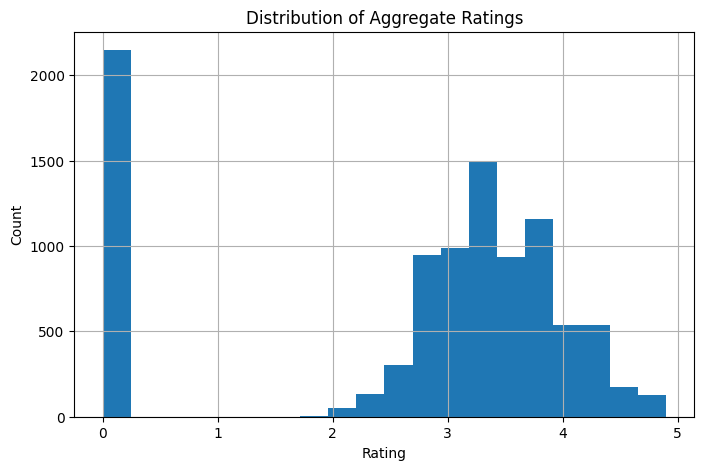

In [24]:
plt.figure(figsize=(8,5))

df['Aggregate rating'].hist(
    bins=20
)

plt.title('Distribution of Aggregate Ratings')

plt.xlabel('Rating')

plt.ylabel('Count')

plt.show()

In [17]:
print(
    df['City']
    .value_counts()
    .head(10)
)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64


In [18]:
print(
    df['Cuisines']
    .value_counts()
    .head(10)
)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


In [26]:
features = [
    'Country Code',
    'City',
    'Cuisines',
    'Average Cost for two',
    'Currency',
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'Switch to order menu',
    'Price range',
    'Votes'
]

target = 'Aggregate rating'

data = df[features + [target]]

data.head()

,Country Code,City,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Votes,Aggregate rating
0,162,Makati City,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,314,4.8
1,162,Makati City,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,591,4.5
2,162,Mandaluyong City,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,270,4.4
3,162,Mandaluyong City,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,365,4.9
4,162,Mandaluyong City,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,229,4.8


In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'City',
    'Cuisines',
    'Currency',
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'Switch to order menu'
]

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

In [28]:
data.head()

,Country Code,City,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Votes,Aggregate rating
0,162,73,920,1100,0,1,0,0,0,3,314,4.8
1,162,73,1111,1200,0,1,0,0,0,3,591,4.5
2,162,75,1671,4000,0,1,0,0,0,4,270,4.4
3,162,75,1126,1500,0,0,0,0,0,4,365,4.9
4,162,75,1122,1500,0,1,0,0,0,4,229,4.8


In [29]:
X = data.drop('Aggregate rating', axis=1)

y = data['Aggregate rating']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (7633, 11)
X_test : (1909, 11)
y_train: (7633,)
y_test : (1909,)


In [32]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [33]:
from sklearn.metrics import mean_squared_error, r2_score

lr_mse = mean_squared_error(
    y_test,
    lr_pred
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("Linear Regression Results")
print("MSE :", lr_mse)
print("R2  :", lr_r2)

Linear Regression Results
MSE : 1.5242079356060187
R2  : 0.3344163742117936


In [34]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [35]:
dt_mse = mean_squared_error(
    y_test,
    dt_pred
)

dt_r2 = r2_score(
    y_test,
    dt_pred
)

print("Decision Tree Results")
print("MSE :", dt_mse)
print("R2  :", dt_r2)

Decision Tree Results
MSE : 0.17381933531226354
R2  : 0.9240974274397581


In [36]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree'
    ],
    'MSE': [
        lr_mse,
        dt_mse
    ],
    'R2 Score': [
        lr_r2,
        dt_r2
    ]
})

comparison

,Model,MSE,R2 Score
0,Linear Regression,1.524208,0.334416
1,Decision Tree,0.173819,0.924097


In [37]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                 Feature  Importance
10                 Votes    0.953702
2               Cuisines    0.015813
3   Average Cost for two    0.010101
0           Country Code    0.007684
1                   City    0.006313
6    Has Online delivery    0.002244
4               Currency    0.001879
9            Price range    0.001171
5      Has Table booking    0.001031
7      Is delivering now    0.000062
8   Switch to order menu    0.000000


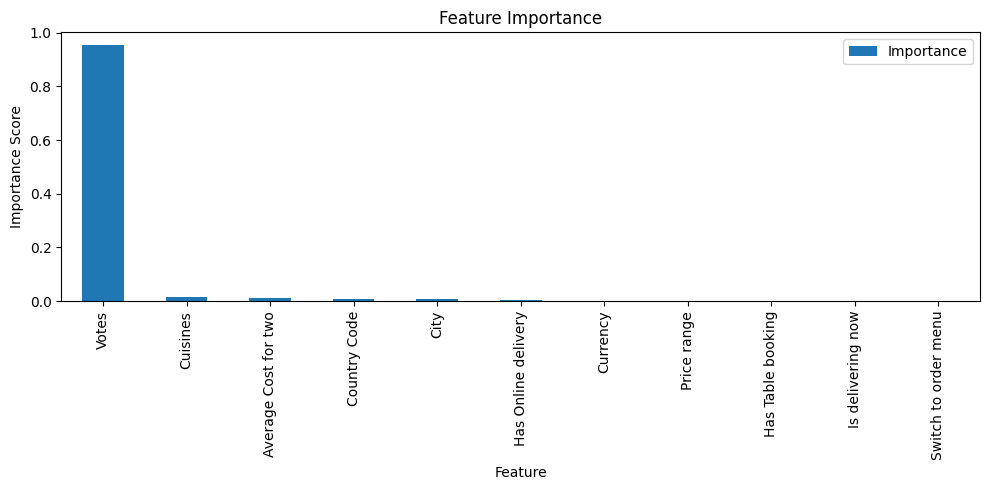

In [38]:
importance.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [39]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [40]:
rf_mse = mean_squared_error(
    y_test,
    rf_pred
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest Results")
print("MSE :", rf_mse)
print("R2  :", rf_r2)

Random Forest Results
MSE : 0.0993073102006081
R2  : 0.9566349721409141


In [41]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MSE': [
        lr_mse,
        dt_mse,
        rf_mse
    ],
    'R2 Score': [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MSE,R2 Score
0,Linear Regression,1.524208,0.334416
1,Decision Tree,0.173819,0.924097
2,Random Forest,0.099307,0.956635


In [42]:
importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by='Importance',
    ascending=False
)

print(importance_rf)

                 Feature  Importance
10                 Votes    0.954050
2               Cuisines    0.015466
3   Average Cost for two    0.009409
0           Country Code    0.008167
1                   City    0.007210
6    Has Online delivery    0.002075
9            Price range    0.001539
5      Has Table booking    0.000987
4               Currency    0.000908
7      Is delivering now    0.000189
8   Switch to order menu    0.000000


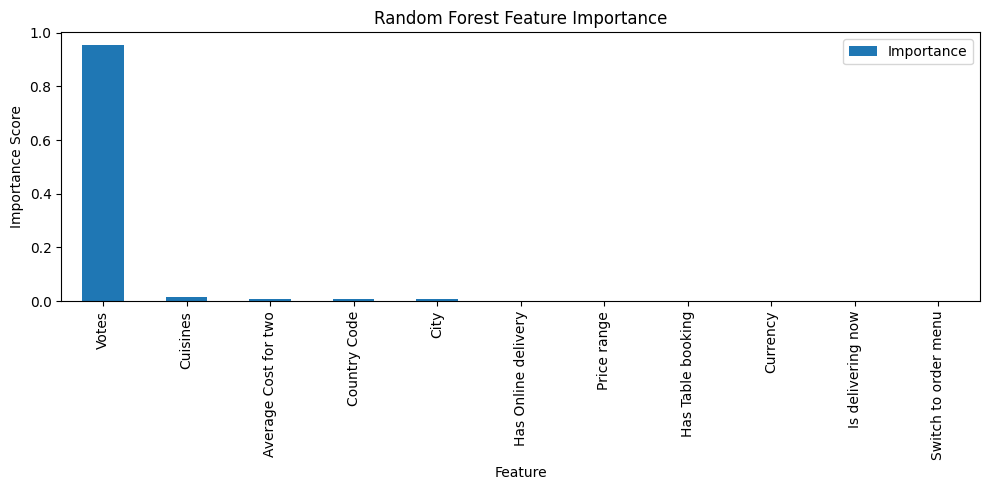

In [43]:
importance_rf.plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("Random Forest Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()